In [20]:
from ydata_profiling import ProfileReport

In [93]:
%matplotlib inline
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
ds = pd.read_csv("loan_data.csv")
ds.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [22]:
pf = ProfileReport(ds, title = 'my report')
pf.to_file('report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████| 14/14 [00:00<00:00, 239.39it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Understanding the data

In [72]:
print(f'dataset Shape :- {ds.shape}')
print("overall infromation on this data :- ")
print(ds.info())
print('\n📊 Statistical Summary:')
ds.describe()

dataset Shape :- (45000, 14)
overall infromation on this data :- 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score               

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


# Exploratory data anylyses (EDA)

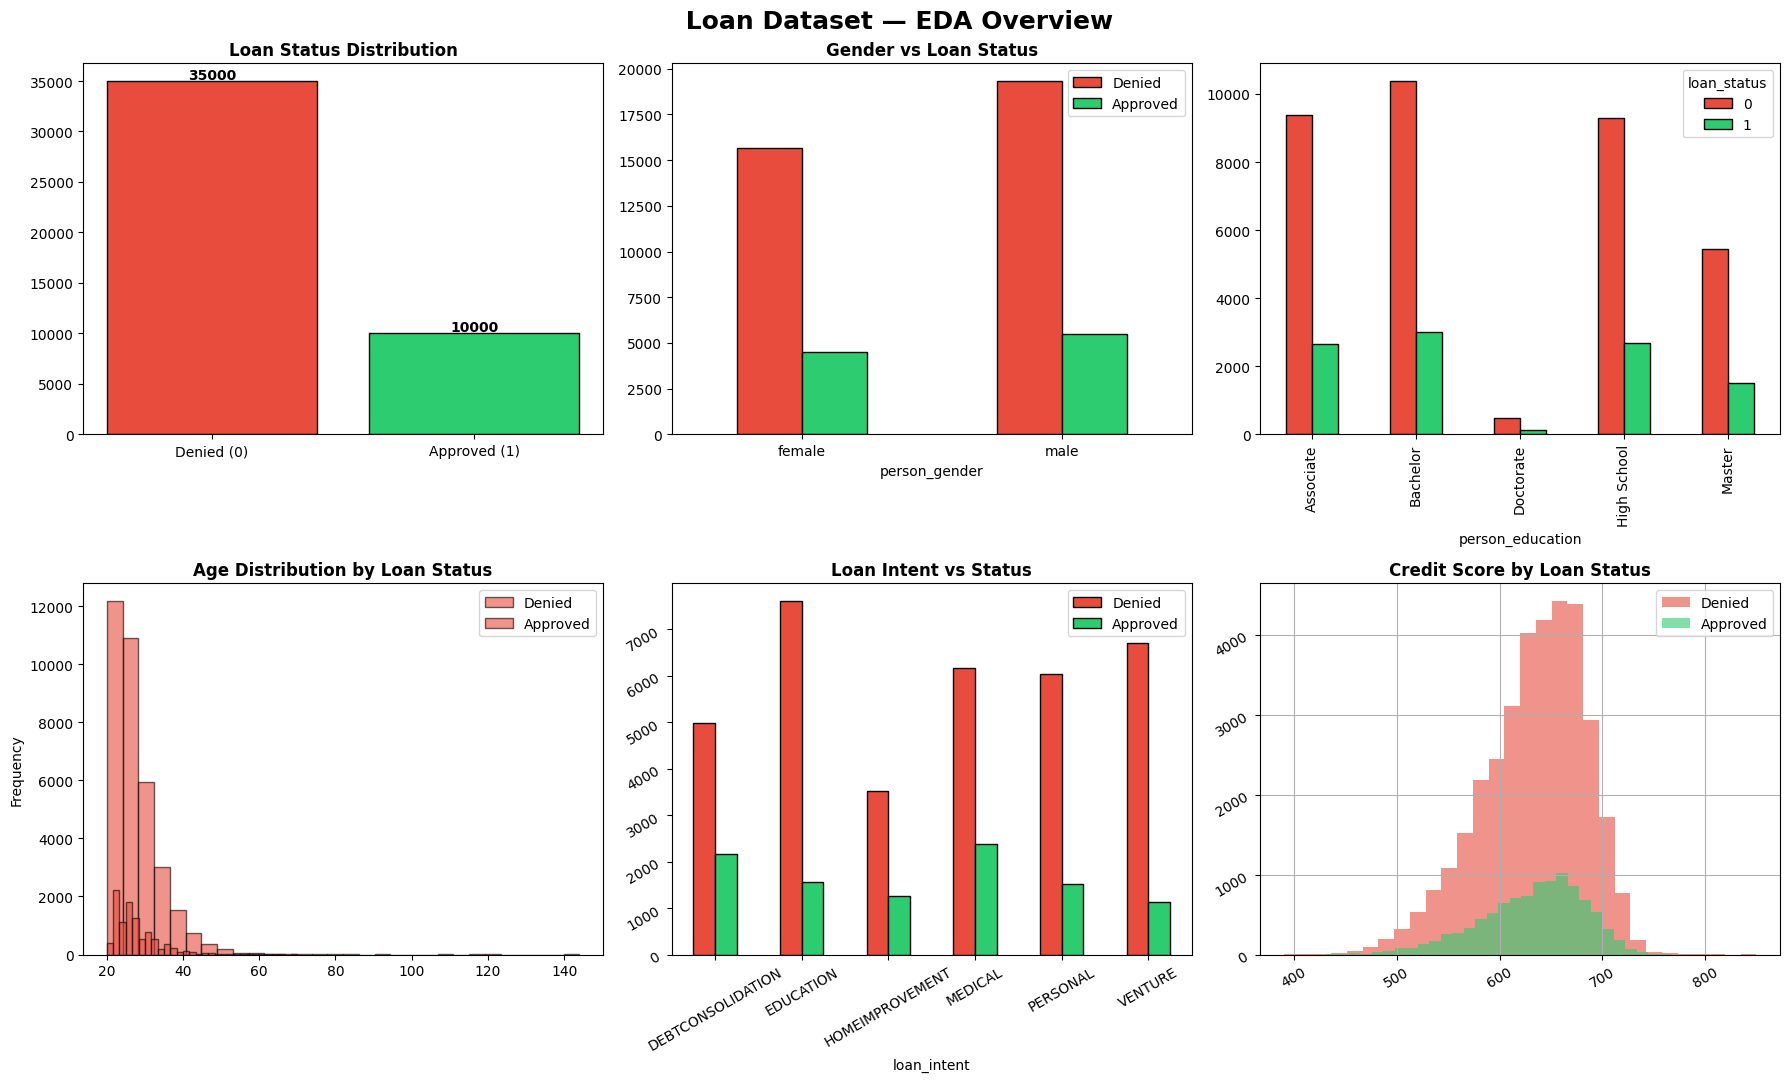

✅ EDA Complete!


In [95]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(' Loan Dataset — EDA Overview', fontsize=18, fontweight='bold')

colors_status = ['#e74c3c', '#2ecc71']

# 1:- Loan Status
vals = ds['loan_status'].value_counts()
axes[0,0].bar(['Denied (0)', 'Approved (1)'], vals.values, color=colors_status, edgecolor='black')
axes[0,0].set_title('Loan Status Distribution', fontweight='bold')
for i, v in enumerate(vals.values):
    axes[0,0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# 2. Gender vs Loan Status
# Yeh **cross table** banata hai — gender aur loan_status ka combination count karta hai

pd.crosstab(ds['person_gender'], ds['loan_status']).plot(
    kind='bar', ax=axes[0,1], color=colors_status, edgecolor='black')
axes[0,1].set_title('Gender vs Loan Status', fontweight='bold')
axes[0,1].legend(['Denied', 'Approved'])
axes[0,1].tick_params(rotation=0)

# 3. Education vs Loan Status
pd.crosstab(ds['person_education'], ds['loan_status']).plot(
    kind = 'bar' , ax = axes[0,2], color = colors_status, edgecolor = 'Black')
axes[1,2].set_title("education vs loan status", fontweight = 'bold')
axes[1,2].legend(['Denied','Approved'])
axes[1,2].tick_params(rotation= 30)

# 4. Age Distribution
ds.groupby('loan_status')['person_age'].plot(
    kind = 'hist', ax = axes[1,0], alpha = 0.6, bins = 30, color = colors_status, edgecolor = 'Black')

axes[1,0].set_title('Age Distribution by Loan Status', fontweight='bold')
axes[1,0].legend(['Denied', 'Approved'])

# 5. Loan Intent
pd.crosstab(ds['loan_intent'], ds['loan_status']).plot(
    kind='bar', ax=axes[1,1], color=colors_status, edgecolor='black')
axes[1,1].set_title('Loan Intent vs Status', fontweight='bold')
axes[1,1].legend(['Denied', 'Approved'])
axes[1,1].tick_params(rotation=30)

# 6. Credit Score Distribution
ds[ds['loan_status']==0]['credit_score'].hist(ax=axes[1,2], alpha=0.6, bins=30, color='#e74c3c', label='Denied')
ds[ds['loan_status']==1]['credit_score'].hist(ax=axes[1,2], alpha=0.6, bins=30, color='#2ecc71', label='Approved')
axes[1,2].set_title('Credit Score by Loan Status', fontweight='bold')
axes[1,2].legend()


plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA Complete!')

# Heatmap correlation 

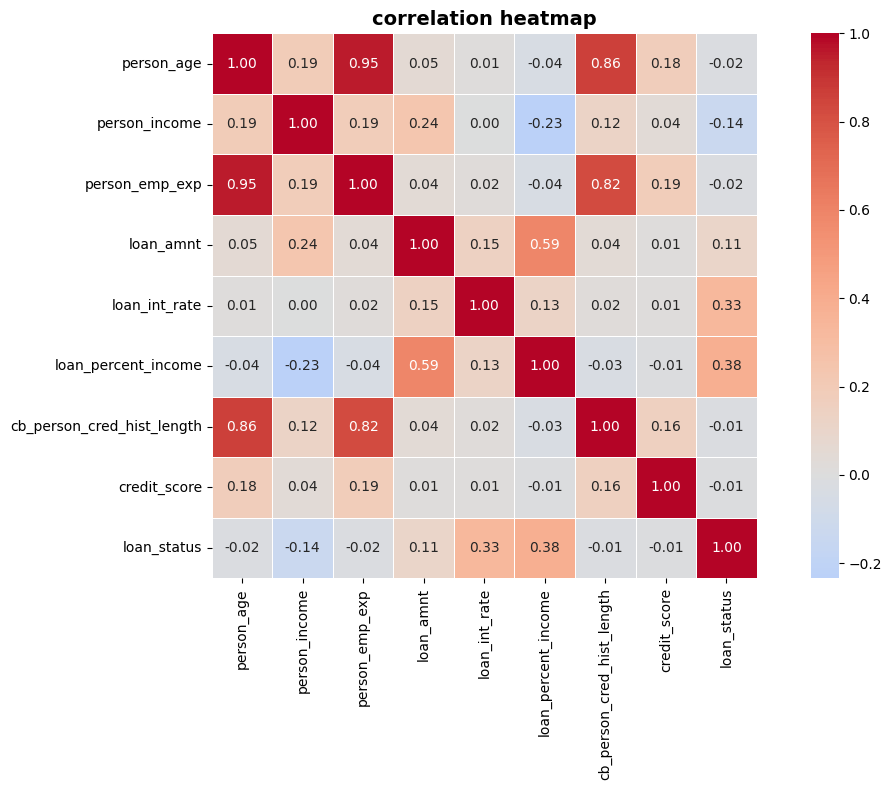

In [97]:
plt.figure(figsize = (12,8))
num_columns = ds.select_dtypes(include=[np.number])
corr = num_columns.corr()
sns.heatmap(corr,annot=True,fmt='.2f',cmap="coolwarm",
           linewidths=0.5, square=True,center=0)
plt.title("correlation heatmap",fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

# preprocessing 

In [98]:
# handlling the missing value
# there is not any one a missing value 
ds.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

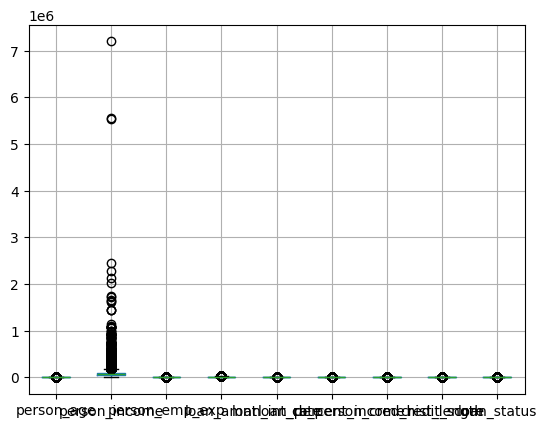

In [99]:
ds.boxplot()
plt.show()

<Axes: ylabel='Count'>

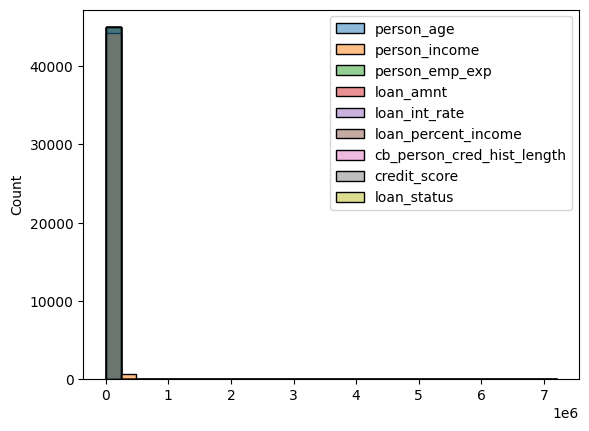

In [103]:
sns.histplot(data = ds, bins=30)
